# Cross-Asset Market & Risk Analytics

Compare asset returns, shared exposures and the risk of an equally weighted SPY, QQQ and GLD portfolio. Brent futures and GBP/USD provide quote-return context only. Run from the project directory using the saved snapshot.


## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from IPython.display import display
from matplotlib.ticker import PercentFormatter

from src.data import load_prices, create_quality_report
from src.metrics import (
    comparison_metrics,
    historical_var,
    wealth_and_drawdown,
)


from src.portfolio import (
    PORTFOLIO_NAME, equal_weights, portfolio_returns as build_portfolio_returns,
    diversification_analysis,
)

PROJECT_DIR = Path.cwd()

if not (PROJECT_DIR / "src" / "data.py").exists():
    raise RuntimeError(
        "Open the project folder and run analysis.ipynb from its root."
    )

DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
for directory in (OUTPUT_DIR, TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TICKERS = ["SPY", "QQQ", "GLD", "BZ=F", "GBPUSD=X"]
ETF_TICKERS = ["SPY", "QQQ", "GLD"]

TRADING_DAYS = 252
ANNUAL_RF = 0.03
ROLLING_WINDOW = 63

DAILY_RF = (
    (1 + ANNUAL_RF) ** (1 / TRADING_DAYS) - 1
)

plt.style.use("seaborn-v0_8-whitegrid")

print("Loaded project modules; using the saved price snapshot.")


Loaded project modules; using the saved price snapshot.


## Saved prices and quality checks

In [2]:
prices = load_prices(
    DATA_DIR / "prices_snapshot.csv",
    TICKERS,
)

quality_report = create_quality_report(prices)

display(prices.head())

display(
    quality_report.style.format({
        "Missing proportion": "{:.2%}",
    })
)

quality_report.to_csv(
    TABLE_DIR / "quality_report.csv"
)

print("Rows:", len(prices))
print("First date:", prices.index.min())
print("Last date:", prices.index.max())


,SPY,QQQ,GLD,BZ=F,GBPUSD=X
Date,,,,,
2019-01-01,NaN,NaN,NaN,NaN,1.273804
2019-01-02,223.805954,147.878387,121.330002,54.910000,1.275429
2019-01-03,218.465332,143.047089,122.430000,55.950001,1.252191
2019-01-04,225.782974,149.167343,121.440002,57.060001,1.262881
2019-01-07,227.563156,150.943253,121.860001,57.330002,1.273496


,Valid observations,Missing observations,Missing proportion,First valid date,Last valid date
SPY,1934,71,3.54%,2019-01-02 00:00:00,2026-09-11 00:00:00
QQQ,1934,71,3.54%,2019-01-02 00:00:00,2026-09-11 00:00:00
GLD,1934,71,3.54%,2019-01-02 00:00:00,2026-09-11 00:00:00
BZ=F,1937,68,3.39%,2019-01-02 00:00:00,2026-09-11 00:00:00
GBPUSD=X,2003,2,0.10%,2019-01-01 00:00:00,2026-09-11 00:00:00


Rows: 2005
First date: 2019-01-01 00:00:00
Last date: 2026-09-11 00:00:00


## Return calendars

In [3]:
spy_dates = prices.index[prices["SPY"].notna()]

etf_prices = prices.loc[
    spy_dates,
    ETF_TICKERS,
].copy()

if etf_prices.isna().any().any():
    raise ValueError(
        "ETF prices are missing on the SPY reference calendar."
    )

etf_returns = (
    etf_prices
    .pct_change(fill_method=None)
    .iloc[1:]
)

if not np.isfinite(etf_returns.to_numpy()).all():
    raise ValueError("Invalid ETF returns.")

raw_cross_asset_returns = prices.pct_change(
    fill_method=None
)

cross_asset_returns = raw_cross_asset_returns.dropna(
    how="any"
)

display(etf_returns.head())

print("ETF return observations:", len(etf_returns))
print("Cross-asset observations:", len(cross_asset_returns))


,SPY,QQQ,GLD
Date,,,
2019-01-03,-0.023863,-0.032671,0.009066
2019-01-04,0.033496,0.042785,-0.008086
2019-01-07,0.007884,0.011905,0.003458
2019-01-08,0.009395,0.009045,-0.002708
2019-01-09,0.004673,0.008150,0.006418


ETF return observations: 1933
Cross-asset observations: 1859


## ETF performance and risk

In [4]:
summary = comparison_metrics(
    etf_returns,
    start_date=etf_prices.index[0],
    annual_rf=ANNUAL_RF,
    trading_days=TRADING_DAYS,
)

metric_formats = {
    column: "{:.2%}"
    for column in summary.columns
}

metric_formats["Observations"] = "{:.0f}"
metric_formats["Sharpe"] = "{:.2f}"

display(summary.style.format(metric_formats).set_caption("ETF Return and Risk"))

summary.to_csv(
    TABLE_DIR / "performance_risk_summary.csv"
)


,Observations,Cumulative return,Annualised return,Annualised volatility,Sharpe,Maximum drawdown,Historical VaR 95%,Historical VaR 99%
SPY,1933,241.50%,17.32%,19.29%,0.77,-33.72%,1.71%,3.37%
QQQ,1933,383.42%,22.74%,23.94%,0.85,-35.12%,2.36%,4.05%
GLD,1933,228.67%,16.73%,17.77%,0.80,-26.40%,1.75%,3.14%


## Monthly returns, wealth, drawdown and rolling volatility

,SPY,QQQ,GLD
Date,,,
2025-10-31 00:00:00,2.38%,4.78%,3.56%
2025-11-30 00:00:00,0.19%,-1.56%,5.37%
2025-12-31 00:00:00,0.08%,-0.67%,2.17%
2026-01-31 00:00:00,1.47%,1.23%,12.27%
2026-02-28 00:00:00,-0.86%,-2.34%,8.72%
2026-03-31 00:00:00,-4.94%,-4.84%,-11.05%
2026-04-30 00:00:00,10.51%,15.69%,-1.54%
2026-05-31 00:00:00,5.26%,10.57%,-1.54%
2026-06-30 00:00:00,-1.03%,-0.15%,-11.68%


Boundary months contain only observed returns; the first and last months may be partial.


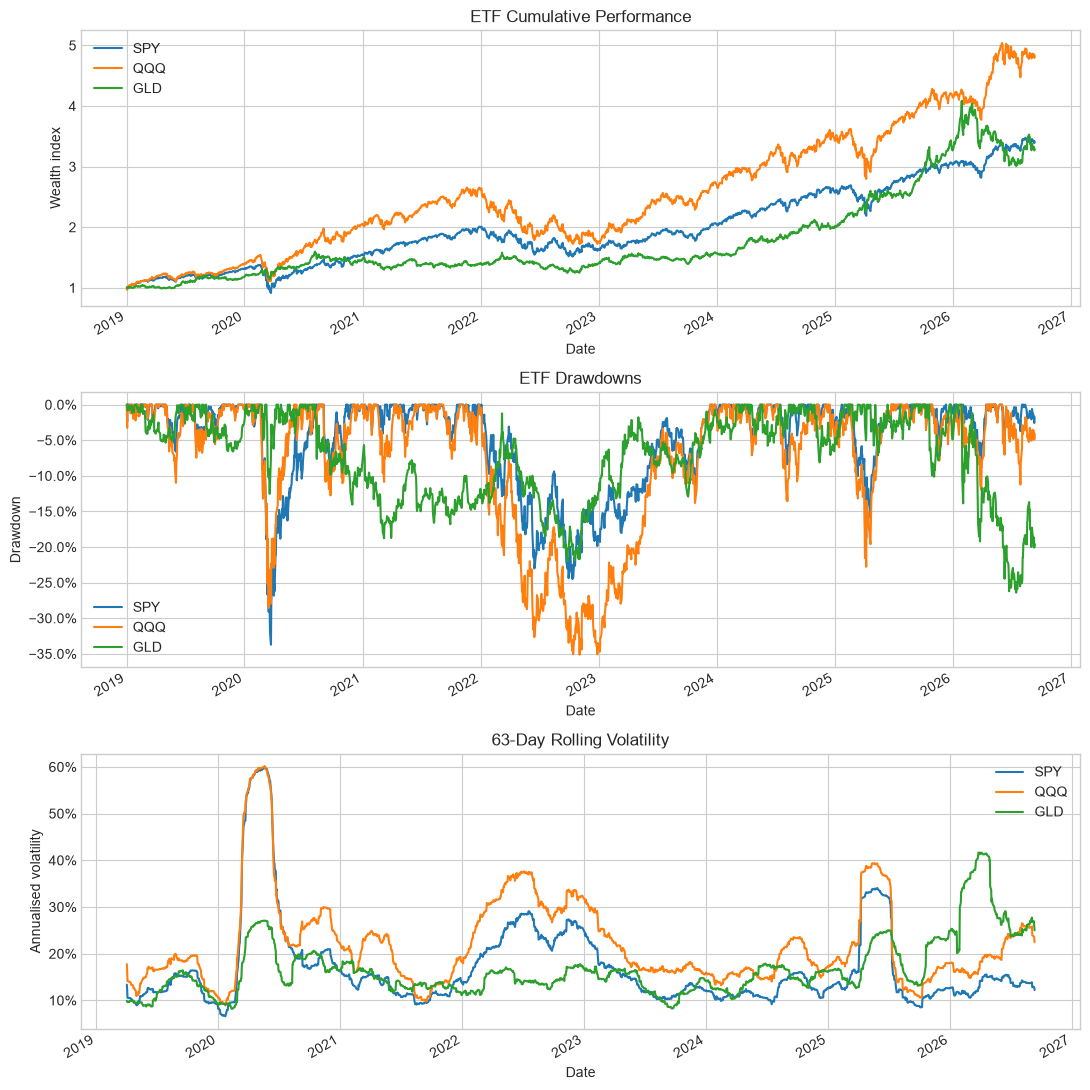

In [5]:
monthly_returns = (
    (1 + etf_returns)
    .resample("ME")
    .prod()
    - 1
)

monthly_counts = (
    etf_returns
    .resample("ME")
    .count()
)

display(monthly_returns.tail(12).style.format("{:.2%}"))

print(
    "Boundary months contain only observed returns; "
    "the first and last months may be partial."
)

monthly_returns.to_csv(
    TABLE_DIR / "monthly_returns.csv"
)

monthly_counts.to_csv(
    TABLE_DIR / "monthly_observation_counts.csv"
)


wealth = pd.DataFrame(index=etf_returns.index)
drawdowns = pd.DataFrame(index=etf_returns.index)

for asset in ETF_TICKERS:
    asset_wealth, asset_drawdown = wealth_and_drawdown(
        etf_returns[asset]
    )

    wealth[asset] = asset_wealth
    drawdowns[asset] = asset_drawdown

initial_wealth = pd.DataFrame(
    1.0,
    index=etf_prices.index[:1],
    columns=ETF_TICKERS,
)

initial_drawdown = pd.DataFrame(
    0.0,
    index=etf_prices.index[:1],
    columns=ETF_TICKERS,
)

wealth_plot = pd.concat([initial_wealth, wealth])
drawdown_plot = pd.concat([initial_drawdown, drawdowns])

rolling_volatility = (
    etf_returns
    .rolling(ROLLING_WINDOW)
    .std()
    * np.sqrt(TRADING_DAYS)
)


fig, axes = plt.subplots(3, 1, figsize=(11, 11))

wealth_plot.plot(
    ax=axes[0],
    title="ETF Cumulative Performance",
)
axes[0].set_ylabel("Wealth index")

drawdown_plot.plot(
    ax=axes[1],
    title="ETF Drawdowns",
)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_ylabel("Drawdown")

rolling_volatility.plot(
    ax=axes[2],
    title="63-Day Rolling Volatility",
)
axes[2].yaxis.set_major_formatter(PercentFormatter(1))
axes[2].set_ylabel("Annualised volatility")

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "performance_and_risk.png",
    dpi=150,
)
plt.show()


## Historical VaR: sign convention

In [6]:
spy_returns = etf_returns["SPY"]

confidence = 0.95

tail_probability = 1 - confidence

return_threshold = spy_returns.quantile(
    tail_probability,
    interpolation="linear",
)

var_95 = -return_threshold

print(f"Return threshold: {return_threshold:.2%}")
print(f"95% Historical VaR: {var_95:.2%}")


Return threshold: -1.71%
95% Historical VaR: 1.71%


## Historical VaR: asset comparison

,Observations,First return date,Last return date,95% Historical VaR,99% Historical VaR
SPY,1933,2019-01-03,2026-09-11,1.71%,3.37%
QQQ,1933,2019-01-03,2026-09-11,2.36%,4.05%
GLD,1933,2019-01-03,2026-09-11,1.75%,3.14%


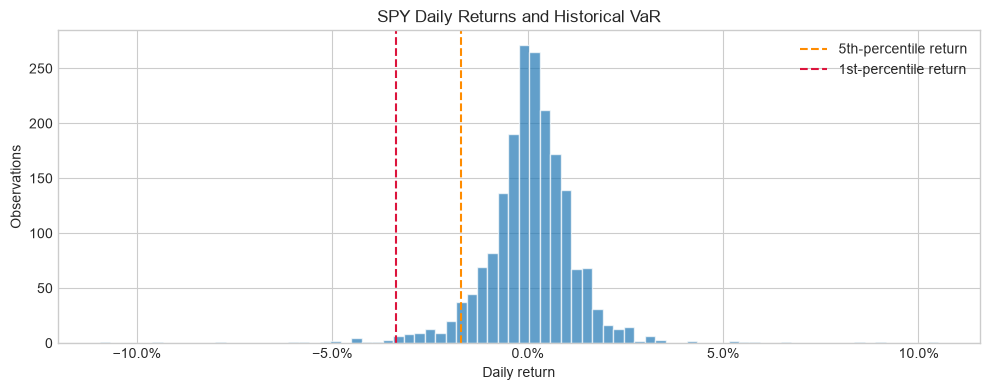

In [7]:
var_table = pd.DataFrame({
    "Observations": etf_returns.count(),
    "First return date": etf_returns.index[0],
    "Last return date": etf_returns.index[-1],
    "95% Historical VaR": etf_returns.apply(
        historical_var,
        confidence=0.95,
    ),
    "99% Historical VaR": etf_returns.apply(
        historical_var,
        confidence=0.99,
    ),
})

display(
    var_table.style.format({
        "First return date": lambda date: date.strftime("%Y-%m-%d"),
        "Last return date": lambda date: date.strftime("%Y-%m-%d"),
        "95% Historical VaR": "{:.2%}",
        "99% Historical VaR": "{:.2%}",
    })
)

var_table.to_csv(
    TABLE_DIR / "historical_var.csv"
)


fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    spy_returns,
    bins=80,
    alpha=0.7,
    edgecolor="white",
)

ax.axvline(
    -var_table.loc["SPY", "95% Historical VaR"],
    color="darkorange",
    linestyle="--",
    label="5th-percentile return",
)

ax.axvline(
    -var_table.loc["SPY", "99% Historical VaR"],
    color="crimson",
    linestyle="--",
    label="1st-percentile return",
)

ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set(
    title="SPY Daily Returns and Historical VaR",
    xlabel="Daily return",
    ylabel="Observations",
)

ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "historical_var.png", dpi=150)
plt.show()


## Cross-asset quote-return correlations

,SPY,QQQ,GLD,BZ=F,GBPUSD=X
SPY,1.000,0.936,0.142,0.183,-0.008
QQQ,0.936,1.000,0.157,0.121,-0.018
GLD,0.142,0.157,1.000,0.046,0.002
BZ=F,0.183,0.121,0.046,1.000,-0.023
GBPUSD=X,-0.008,-0.018,0.002,-0.023,1.000


Common return sample: 2019-01-03 to 2026-09-11
Observations: 1859


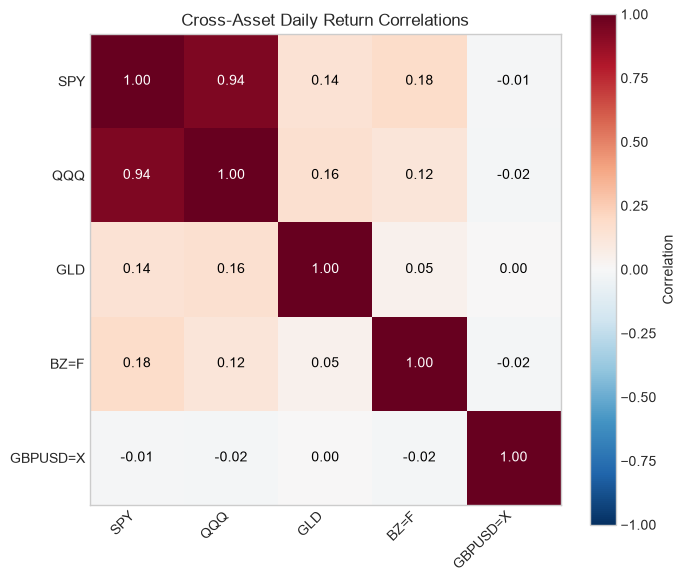

In [8]:
correlation_matrix = cross_asset_returns.corr()

display(correlation_matrix.round(3))

correlation_matrix.to_csv(
    TABLE_DIR / "correlation_matrix.csv"
)

print(
    "Common return sample:",
    cross_asset_returns.index.min().date(),
    "to",
    cross_asset_returns.index.max().date(),
)

print("Observations:", len(cross_asset_returns))


fig, ax = plt.subplots(figsize=(7, 6))

heatmap = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
)

positions = range(len(correlation_matrix.columns))

ax.set_xticks(positions)
ax.set_yticks(positions)
ax.grid(False)
ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(correlation_matrix.index)

for row in positions:
    for column in positions:
        value = correlation_matrix.iloc[row, column]

        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if abs(value) > 0.6 else "black",
        )

fig.colorbar(heatmap, ax=ax, label="Correlation")

ax.set_title("Cross-Asset Daily Return Correlations")

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "correlation_matrix.png",
    dpi=150,
)
plt.show()


## QQQ versus SPY: OLS with HAC inference

In [9]:
equity_excess = (
    etf_returns[["SPY", "QQQ"]]
    - DAILY_RF
)

y = equity_excess["QQQ"]
x = equity_excess["SPY"]

X = sm.add_constant(x)

model = sm.OLS(y, X)

market_model = model.fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 5},
)

ci = market_model.conf_int()

regression_summary = pd.DataFrame({
    "Coefficient": market_model.params,
    "HAC standard error": market_model.bse,
    "p-value": market_model.pvalues,
    "CI lower": ci[0],
    "CI upper": ci[1],
})

display(
    regression_summary.style.format({
        "Coefficient": "{:.6f}",
        "HAC standard error": "{:.6f}",
        "p-value": lambda value: "<0.001" if value < 0.001 else f"{value:.3f}",
        "CI lower": "{:.6f}",
        "CI upper": "{:.6f}",
    })
)

print(f"R-squared: {market_model.rsquared:.3f}")
print(f"Observations: {int(market_model.nobs)}")

regression_summary.to_csv(
    TABLE_DIR / "regression_summary.csv"
)


,Coefficient,HAC standard error,p-value,CI lower,CI upper
const,0.000125,0.000121,0.302,-0.000112,0.000362
SPY,1.159994,0.029862,<0.001,1.101466,1.218523


R-squared: 0.874
Observations: 1933


## Residual diagnostics

Residual mean                     3.589702e-21
Residual standard deviation       5.360166e-03
Residual lag-1 autocorrelation    8.824501e-03
dtype: float64

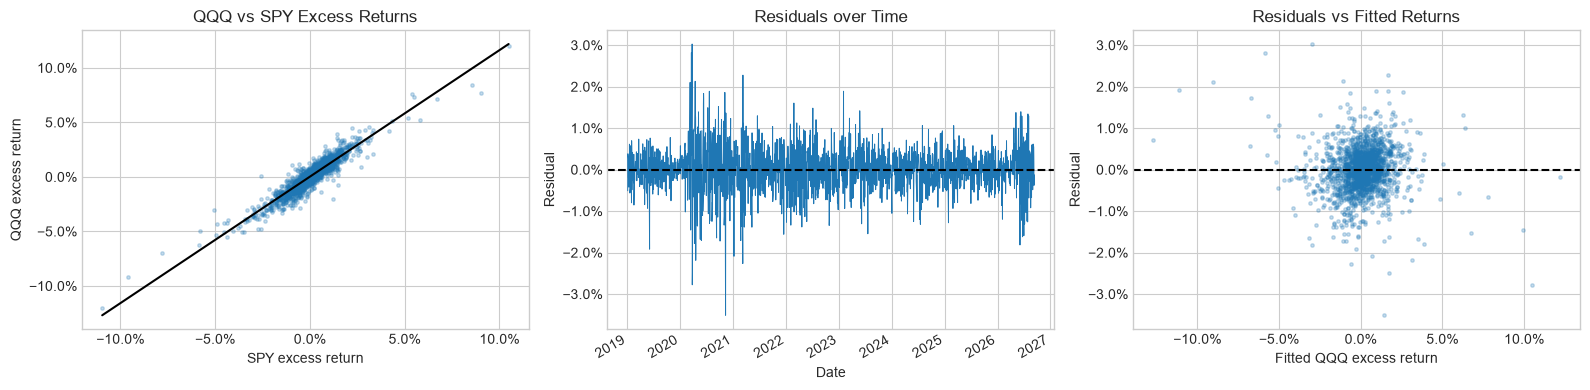

In [10]:
fitted_returns = market_model.fittedvalues
residuals = market_model.resid

residual_summary = pd.Series({
    "Residual mean": residuals.mean(),
    "Residual standard deviation": residuals.std(),
    "Residual lag-1 autocorrelation": residuals.autocorr(lag=1),
})

display(residual_summary)

residual_summary.to_csv(
    TABLE_DIR / "residual_summary.csv",
    header=["Value"],
)


fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(x, y, s=6, alpha=0.25)

xline = np.array([x.min(), x.max()])

yline = (
    market_model.params["const"]
    + market_model.params["SPY"] * xline
)

axes[0].plot(xline, yline, color="black")

axes[0].set(
    title="QQQ vs SPY Excess Returns",
    xlabel="SPY excess return",
    ylabel="QQQ excess return",
)

residuals.plot(ax=axes[1], linewidth=0.7)

axes[1].axhline(0, color="black", linestyle="--")

axes[1].set(
    title="Residuals over Time",
    ylabel="Residual",
)

axes[2].scatter(
    fitted_returns,
    residuals,
    s=6,
    alpha=0.25,
)

axes[2].axhline(0, color="black", linestyle="--")

axes[2].set(
    title="Residuals vs Fitted Returns",
    xlabel="Fitted QQQ excess return",
    ylabel="Residual",
)

for ax in axes:
    ax.yaxis.set_major_formatter(PercentFormatter(1))
for ax in (axes[0], axes[2]):
    ax.xaxis.set_major_formatter(PercentFormatter(1))

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "regression_diagnostics.png",
    dpi=150,
)

plt.show()


## Equal-weight ETF portfolio

SPY, QQQ and GLD each receive one third of capital, rebalanced daily before costs. All portfolio comparisons use the same complete ETF return calendar.


In [11]:
weights = equal_weights(etf_returns)
portfolio_returns = build_portfolio_returns(etf_returns, weights)
returns_with_portfolio = etf_returns.assign(**{PORTFOLIO_NAME: portfolio_returns})
comparison = comparison_metrics(
    returns_with_portfolio, start_date=etf_prices.index[0],
    annual_rf=ANNUAL_RF, trading_days=TRADING_DAYS,
)
portfolio_summary = comparison.loc[PORTFOLIO_NAME].rename("Value")
display(weights.to_frame().style.format("{:.2%}"))
display(comparison.style.format(metric_formats).set_caption("ETFs and Equal-Weight Portfolio"))


,Weight
SPY,33.33%
QQQ,33.33%
GLD,33.33%


,Observations,Cumulative return,Annualised return,Annualised volatility,Sharpe,Maximum drawdown,Historical VaR 95%,Historical VaR 99%
SPY,1933,241.50%,17.32%,19.29%,0.77,-33.72%,1.71%,3.37%
QQQ,1933,383.42%,22.74%,23.94%,0.85,-35.12%,2.36%,4.05%
GLD,1933,228.67%,16.73%,17.77%,0.80,-26.40%,1.75%,3.14%
Equal Weight Portfolio,1933,302.77%,19.86%,16.11%,1.03,-22.97%,1.57%,2.80%


## Diversification

Compare portfolio volatility with the weighted average of individual asset volatilities, a perfect-correlation benchmark. Report the difference in percentage points and relative to the benchmark; the diversification ratio is benchmark volatility divided by portfolio volatility.


In [12]:
diversification, risk_contributions, annual_covariance = diversification_analysis(
    etf_returns, weights, TRADING_DAYS,
)
etf_correlation = etf_returns.corr()
diversification_display = pd.DataFrame({
    "Value": [
        f"{diversification['Weighted standalone volatility']:.2%}",
        f"{diversification['Portfolio volatility']:.2%}",
        f"{100 * diversification['Volatility reduction (absolute)']:.2f} percentage points",
        f"{diversification['Volatility reduction (relative)']:.2%}",
        f"{diversification['Diversification ratio']:.2f}",
    ],
}, index=diversification.index)
display(diversification_display.style.set_caption("Diversification against a Perfect-Correlation Benchmark"))
display(risk_contributions.style.format({
    "Weight": "{:.2%}", "Standalone volatility": "{:.2%}",
    "Volatility contribution": lambda value: f"{100 * value:.2f} pp",
}).set_caption("Contributions to Annualised Portfolio Volatility"))
assert np.isclose(
    risk_contributions["Volatility contribution"].sum(),
    comparison.loc[PORTFOLIO_NAME, "Annualised volatility"],
)


,Value
Weighted standalone volatility,20.33%
Portfolio volatility,16.11%
Volatility reduction (absolute),4.22 percentage points
Volatility reduction (relative),20.78%
Diversification ratio,1.26


,Weight,Standalone volatility,Volatility contribution
SPY,33.33%,19.29%,5.85 pp
QQQ,33.33%,23.94%,7.35 pp
GLD,33.33%,17.77%,2.91 pp


## Portfolio performance and risk

Wealth starts at 1 on the first price date, which is included in drawdown peaks. Rolling volatility uses 63 trading observations.


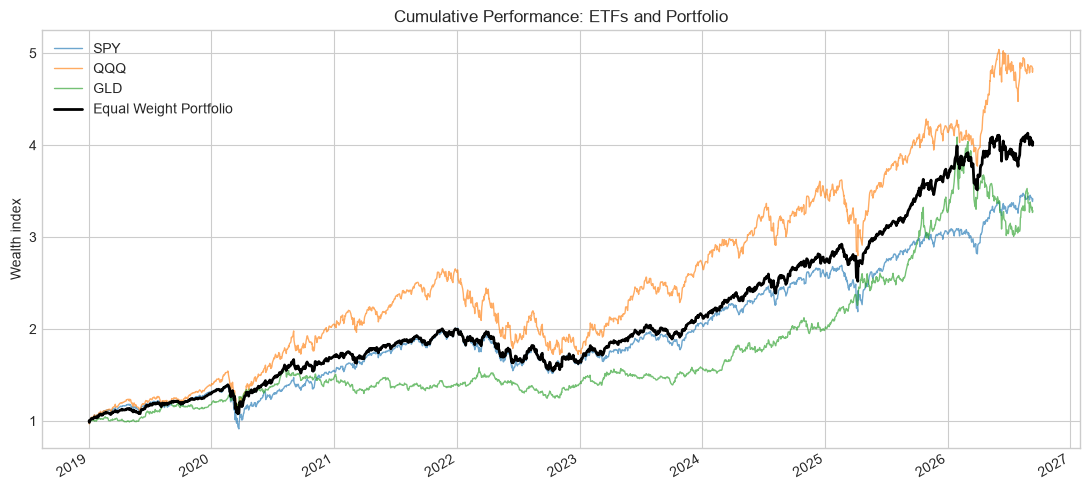

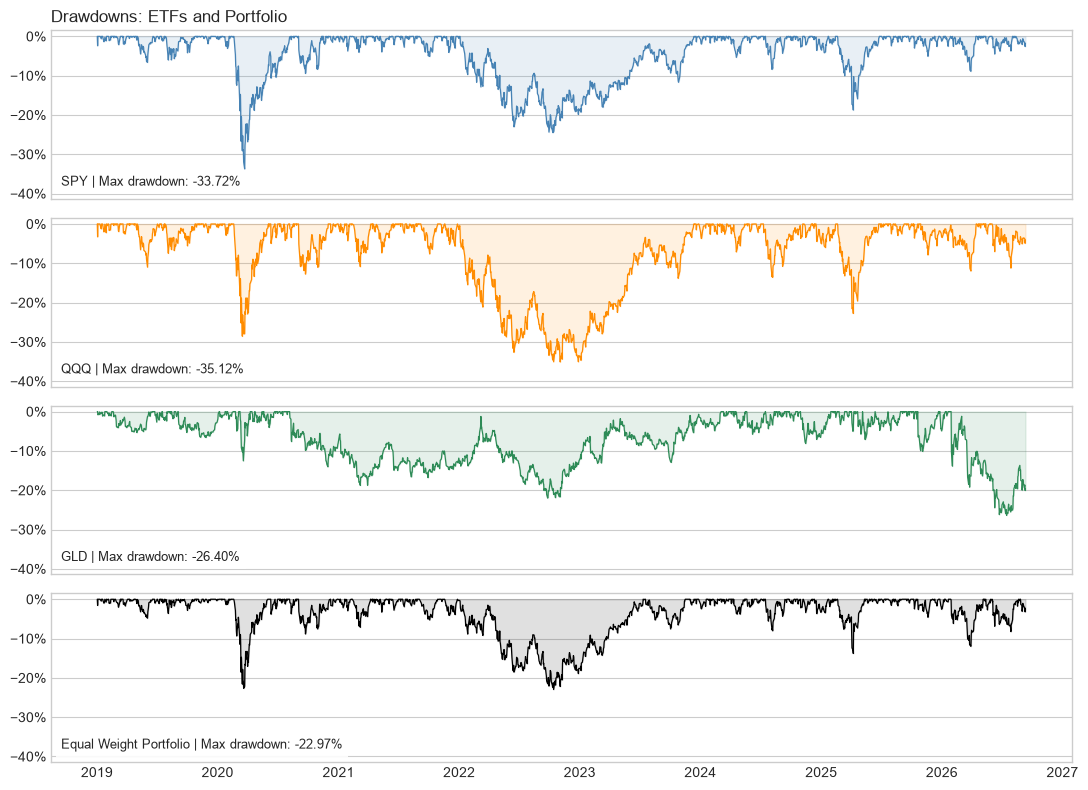

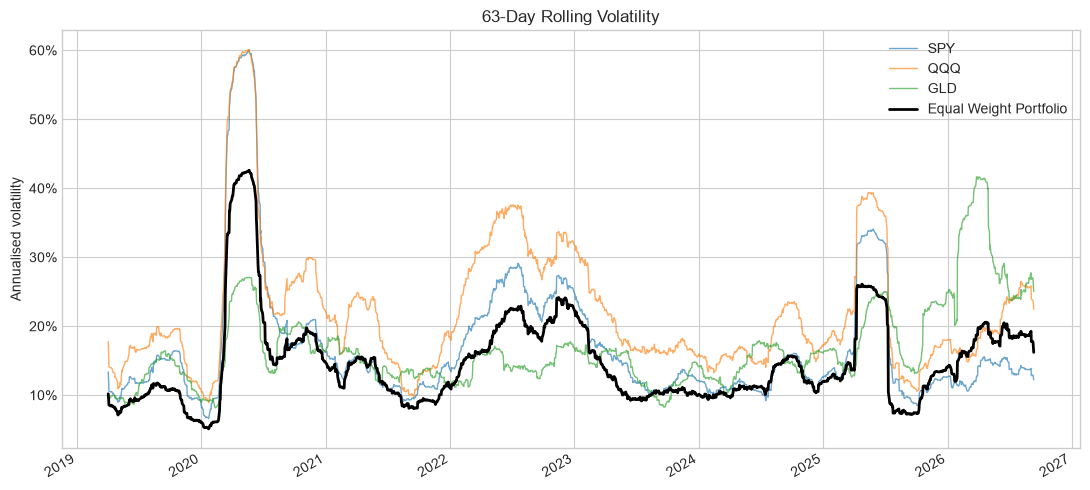

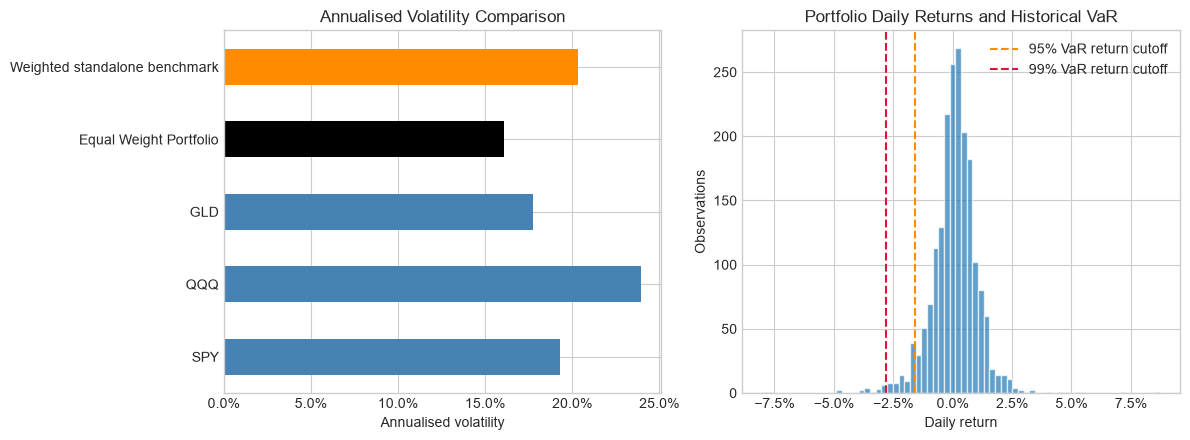

In [13]:
wealth_all = pd.DataFrame(index=returns_with_portfolio.index)
drawdowns_all = pd.DataFrame(index=returns_with_portfolio.index)
for asset in returns_with_portfolio:
    wealth_all[asset], drawdowns_all[asset] = wealth_and_drawdown(returns_with_portfolio[asset])
initial = pd.DataFrame(1.0, index=etf_prices.index[:1], columns=returns_with_portfolio.columns)
wealth_all_plot = pd.concat([initial, wealth_all])
drawdowns_all_plot = pd.concat([initial * 0, drawdowns_all])
rolling_volatility_all = returns_with_portfolio.rolling(ROLLING_WINDOW).std() * np.sqrt(TRADING_DAYS)

plots = [
    (wealth_all_plot, "cumulative_wealth", "Cumulative Performance: ETFs and Portfolio", "Wealth index", False),
    (drawdowns_all_plot, "drawdown_comparison", "Drawdowns: ETFs and Portfolio", "Drawdown", True),
    (rolling_volatility_all, "rolling_volatility", f"{ROLLING_WINDOW}-Day Rolling Volatility", "Annualised volatility", True),
]
for frame, filename, title, ylabel, percentage in plots:
    if filename == "drawdown_comparison":
        fig, axes = plt.subplots(len(frame.columns), 1, figsize=(11, 8), sharex=True, sharey=True)
        lower = min(-0.05, float(frame.min().min()) * 1.18)
        for ax, asset, colour in zip(axes, frame.columns, ["steelblue", "darkorange", "seagreen", "black"]):
            series = frame[asset]
            ax.plot(series.index, series, color=colour, linewidth=0.9)
            ax.fill_between(series.index, series, 0, color=colour, alpha=0.12)
            ax.text(0.01, 0.08, f"{asset} | Max drawdown: {series.min():.2%}",
                    transform=ax.transAxes, fontsize=9,
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.9))
            ax.set_ylim(lower, 0.015)
            ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
            ax.grid(axis="x", visible=False)
        axes[0].set_title(title, loc="left")
    else:
        fig, ax = plt.subplots(figsize=(11, 5))
        frame.drop(columns=PORTFOLIO_NAME).plot(ax=ax, alpha=0.65, linewidth=1)
        frame[PORTFOLIO_NAME].plot(ax=ax, color="black", linewidth=2, label=PORTFOLIO_NAME)
        ax.set(title=title, ylabel=ylabel, xlabel="")
        if percentage:
            ax.yaxis.set_major_formatter(PercentFormatter(1))
        ax.legend(loc="best")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"{filename}.png", dpi=180)
    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
vol_comparison = comparison["Annualised volatility"].copy()
vol_comparison.loc["Weighted standalone benchmark"] = diversification["Weighted standalone volatility"]
vol_comparison.plot.barh(ax=axes[0], color=["steelblue"] * 3 + ["black", "darkorange"])
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].set(title="Annualised Volatility Comparison", xlabel="Annualised volatility")
axes[1].hist(portfolio_returns, bins=70, alpha=0.7, edgecolor="white")
for confidence, colour in [(0.95, "darkorange"), (0.99, "crimson")]:
    cutoff = -historical_var(portfolio_returns, confidence)
    axes[1].axvline(cutoff, color=colour, linestyle="--", label=f"{confidence:.0%} VaR return cutoff")
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].set(title="Portfolio Daily Returns and Historical VaR", xlabel="Daily return", ylabel="Observations")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "portfolio_diversification_and_var.png", dpi=180)
plt.show()


## Save tables and reproducibility metadata

In [14]:
import hashlib
import json
import platform
from importlib.metadata import version

tables = {
    "portfolio_weights": weights.to_frame(),
    "portfolio_summary": portfolio_summary.to_frame(),
    "asset_portfolio_comparison": comparison,
    "diversification_summary": diversification.to_frame(),
    "risk_contributions": risk_contributions,
    "annual_covariance": annual_covariance,
    "etf_correlation_matrix": etf_correlation,
    "daily_returns_with_portfolio": returns_with_portfolio,
    "wealth_with_portfolio": wealth_all_plot,
    "drawdowns_with_portfolio": drawdowns_all_plot,
    "rolling_volatility_with_portfolio": rolling_volatility_all,
    "regression_fit": pd.DataFrame({"Actual excess return": y, "Fitted excess return": fitted_returns, "Residual": residuals}),
    "regression_model_statistics": pd.Series({"R-squared": market_model.rsquared, "Observations": market_model.nobs, "HAC maxlags": 5}).to_frame("Value"),
}
for name, table in tables.items():
    table.to_csv(TABLE_DIR / f"{name}.csv")

metadata = {
    "snapshot": "data/prices_snapshot.csv",
    "snapshot_sha256": hashlib.sha256((DATA_DIR / "prices_snapshot.csv").read_bytes()).hexdigest(),
    "source_note": "Inherited saved snapshot; original download timestamp and adjustment settings were not recorded. The available downloader uses yfinance auto_adjust=True; this does not establish the provenance of the existing snapshot.",
    "first_price_date": str(etf_prices.index[0].date()),
    "last_price_date": str(etf_prices.index[-1].date()),
    "etf_return_observations": len(etf_returns),
    "cross_asset_return_observations": len(cross_asset_returns),
    "portfolio_assets": ETF_TICKERS,
    "annual_rf": ANNUAL_RF,
    "trading_days": TRADING_DAYS,
    "rolling_window": ROLLING_WINDOW,
    "rebalancing": "daily, constant weights, before costs",
    "python": platform.python_version(),
    "packages": {name: version(name) for name in ["numpy", "pandas", "matplotlib", "statsmodels", "yfinance", "nbformat", "nbclient"]},
}
(OUTPUT_DIR / "run_metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
print(f"Saved {len(tables)} portfolio and regression tables to outputs/tables/.")


Saved 13 portfolio and regression tables to outputs/tables/.


## Results

The figures below are generated from this run. For the interpretation, see [Key Findings](KEY_SUMMARY.md). HAC adjusts regression inference; Historical VaR is a loss threshold, not a maximum possible loss.


In [15]:
from IPython.display import Markdown

p = comparison.loc[PORTFOLIO_NAME]
lowest = summary["Annualised volatility"].idxmin()
highest = summary["Annualised volatility"].idxmax()
best_sharpe = comparison["Sharpe"].idxmax()
beta_ci = ci.loc["SPY"]
beta_p_text = "<0.001" if market_model.pvalues["SPY"] < 0.001 else f"={market_model.pvalues['SPY']:.3g}"
comments = [
    f"Sample: {etf_prices.index[0].date()} to {etf_prices.index[-1].date()}, with {len(etf_returns):,} ETF return observations.",
    f"The daily-rebalanced equal-weight ETF portfolio had a CAGR of {p['Annualised return']:.2%}, annualised volatility of {p['Annualised volatility']:.2%}, and Sharpe of {p['Sharpe']:.2f} using a {ANNUAL_RF:.0%} annual risk-free assumption.",
    f"Weighted standalone volatility was {diversification['Weighted standalone volatility']:.2%}; portfolio volatility was {diversification['Portfolio volatility']:.2%}. The reduction was {100 * diversification['Volatility reduction (absolute)']:.2f} percentage points ({diversification['Volatility reduction (relative)']:.1%} relative).",
    f"Among the ETFs, {lowest} had the lowest volatility ({summary.loc[lowest, 'Annualised volatility']:.2%}) and {highest} the highest ({summary.loc[highest, 'Annualised volatility']:.2%}). {best_sharpe} had the highest sample Sharpe ({comparison.loc[best_sharpe, 'Sharpe']:.2f}) among ETFs and portfolio.",
    f"Portfolio maximum drawdown was {p['Maximum drawdown']:.2%}. One-day historical VaR was {p['Historical VaR 95%']:.2%} at 95% and {p['Historical VaR 99%']:.2%} at 99%, reported using the loss convention.",
    f"QQQ-on-SPY excess-return beta was {market_model.params['SPY']:.3f} (HAC 95% CI {beta_ci.iloc[0]:.3f}–{beta_ci.iloc[1]:.3f}, p{beta_p_text}); R-squared was {market_model.rsquared:.3f}. Daily alpha was {market_model.params['const']:.6f} (HAC p={market_model.pvalues['const']:.3g}).",
    f"Residual lag-1 autocorrelation was {residuals.autocorr(1):.3f}. This descriptive statistic alone is not a formal whiteness test; residual charts should also be inspected for changing variance and outliers.",
    f"ETF correlations use {len(etf_returns):,} common ETF observations; the five-asset correlation uses {len(cross_asset_returns):,} complete quote-return observations. Different market closing times limit same-day comparisons.",
]
limitations = """The portfolio excludes futures and FX quotes, which require separate funding, roll and currency conventions. No transaction costs, taxes or slippage are modelled. A constant 3% risk-free rate is an assumption. The saved snapshot's original download metadata is unavailable, so adjusted-price provenance cannot be verified from the CSV alone. CAGR and wealth describe the supplied price series; total-return interpretation depends on its adjustment convention. Historical estimates and daily rebalancing results do not establish future performance."""
report = "# Analytical comments\n\n" + "\n\n".join("- " + item for item in comments) + "\n\n## Limitations\n\n" + limitations + "\n"
(OUTPUT_DIR / "analysis_comments.md").write_text(report)
display(Markdown(report))


# Analytical comments

- Sample: 2019-01-02 to 2026-09-11, with 1,933 ETF return observations.

- The daily-rebalanced equal-weight ETF portfolio had a CAGR of 19.86%, annualised volatility of 16.11%, and Sharpe of 1.03 using a 3% annual risk-free assumption.

- Weighted standalone volatility was 20.33%; portfolio volatility was 16.11%. The reduction was 4.22 percentage points (20.8% relative).

- Among the ETFs, GLD had the lowest volatility (17.77%) and QQQ the highest (23.94%). Equal Weight Portfolio had the highest sample Sharpe (1.03) among ETFs and portfolio.

- Portfolio maximum drawdown was -22.97%. One-day historical VaR was 1.57% at 95% and 2.80% at 99%, reported using the loss convention.

- QQQ-on-SPY excess-return beta was 1.160 (HAC 95% CI 1.101–1.219, p<0.001); R-squared was 0.874. Daily alpha was 0.000125 (HAC p=0.302).

- Residual lag-1 autocorrelation was 0.009. This descriptive statistic alone is not a formal whiteness test; residual charts should also be inspected for changing variance and outliers.

- ETF correlations use 1,933 common ETF observations; the five-asset correlation uses 1,859 complete quote-return observations. Different market closing times limit same-day comparisons.

## Limitations

The portfolio excludes futures and FX quotes, which require separate funding, roll and currency conventions. No transaction costs, taxes or slippage are modelled. A constant 3% risk-free rate is an assumption. The saved snapshot's original download metadata is unavailable, so adjusted-price provenance cannot be verified from the CSV alone. CAGR and wealth describe the supplied price series; total-return interpretation depends on its adjustment convention. Historical estimates and daily rebalancing results do not establish future performance.
